In [30]:
import requests
from dotenv import load_dotenv
import os

# Configurare din .env [cite: 60]
load_dotenv()

CLIENT_ID = os.getenv("CLIENT_ID")
CLIENT_SECRET = os.getenv("CLIENT_SECRET")

def get_token():
    auth_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    data = {
        "grant_type": "client_credentials",
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET
    }
    response = requests.post(auth_url, data=data)
    return response.json()["access_token"]

def get_soil_moisture_data(bbox):
    token = get_token()
    url = "https://sh.dataspace.copernicus.eu/api/v1/process"
    
    # Evalscript: Calculează umiditatea brută din Sentinel-1 GRD [cite: 97, 109]
    evalscript = """
    //VERSION=3
    function setup() {
      return {
        input: ["VV"],
        output: { bands: 1, sampleType: "FLOAT32" }
      };
    }
    function evaluatePixel(samples) {
  if (samples.VV <= 0) return [NaN];
  return [10 * Math.log10(samples.VV)];
}
    """

    headers = {
        "Authorization": f"Bearer {token}",
    }

    payload = {
        "input": {
            "bounds": { "properties": { "crs": "http://www.opengis.net/def/crs/OGC/1.3/CRS84" }, "bbox": bbox },
            "data": [{ "type": "S1GRD" }]
        },
        "output": {
            "responses": [{ "format": { "type": "image/tiff" } }] },
            "evalscript": evalscript
    }

    response = requests.post(url, headers=headers, json=payload)
    return response.content

b'MM\x00*\x00\x00\x00\x08\x00\x11\x01\x00\x00\x03\x00\x00\x00\x01\x01\x00\x00\x00\x01\x01\x00\x03\x00\x00\x00\x01\x01\x00\x00\x00\x01\x02\x00\x03\x00\x00\x00\x01\x00 \x00\x00\x01\x03\x00\x03\x00\x00\x00\x01\x80\xb2\x00\x00\x01\x06\x00\x03\x00\x00\x00\x01\x00\x01\x00\x00\x01\x11\x00\x04\x00\x00\x00 \x00\x00\x00\xdc\x01\x15\x00\x03\x00\x00\x00\x01\x00\x01\x00\x00\x01\x16\x00\x03\x00\x00\x00\x01\x00\x08\x00\x00\x01\x17\x00\x04\x00\x00\x00 \x00\x00\x01\\\x01\x1a\x00\x05\x00\x00\x00\x01\x00\x00\x01\xdc\x01\x1b\x00\x05\x00\x00\x00\x01\x00\x00\x01\xe4\x01(\x00\x03\x00\x00\x00\x01\x00\x01\x00\x00\x01S\x00\x03\x00\x00\x00\x01\x00\x03\x00\x00\x83\x0e\x00\x0c\x00\x00\x00\x03\x00\x00\x01\xec\x84\x82\x00\x0c\x00\x00\x00\x06\x00\x00\x02\x04\x87\xaf\x00\x03\x00\x00\x00\x1c\x00\x00\x024\x87\xb1\x00\x02\x00\x00\x00\x0f\x00\x00\x02l\x00\x00\x00\x00\x00\x00\x00\x00\x02{\x00\x00\x06\xd0\x00\x00\x0b3\x00\x00\x0fy\x00\x00\x13\xe2\x00\x00\x18`\x00\x00\x1c\xc1\x00\x00!\x13\x00\x00%_\x00\x00)\xb1\x00\x00.\n\x0

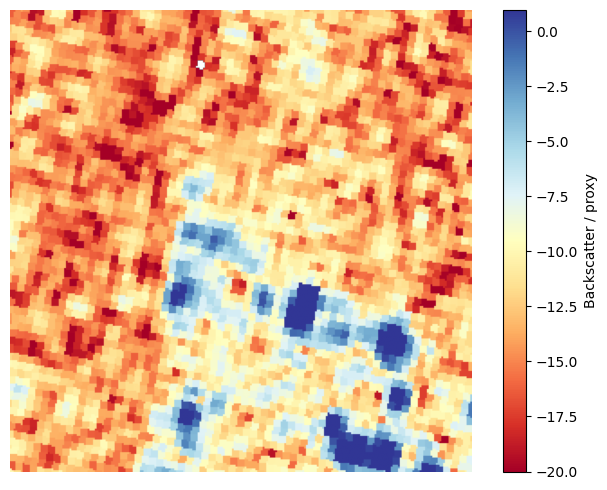

In [35]:
from io import BytesIO
from PIL import Image
import numpy as np

bbox = [27.775648, 45.625941, 27.78378, 45.631447]

result = get_soil_moisture_data(bbox)
print(result)

import matplotlib.pyplot as plt

arr = []

from io import BytesIO
import numpy as np
import rasterio
from rasterio.io import MemoryFile
import matplotlib.pyplot as plt

with MemoryFile(result) as memfile:
    with memfile.open() as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata

        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr)

        arr[~np.isfinite(arr)] = np.nan
        arr[(arr < -50) | (arr > 50)] = np.nan

if arr.ndim == 3 and arr.shape[2] == 1:
    arr = arr[:, :, 0]

valid = arr[np.isfinite(arr)]
vmin, vmax = np.percentile(valid, [2, 98])

plt.figure(figsize=(8, 6))
plt.imshow(arr, cmap="RdYlBu", vmin=vmin, vmax=vmax)
plt.colorbar(label="Backscatter / proxy")
plt.axis("off")
plt.show()

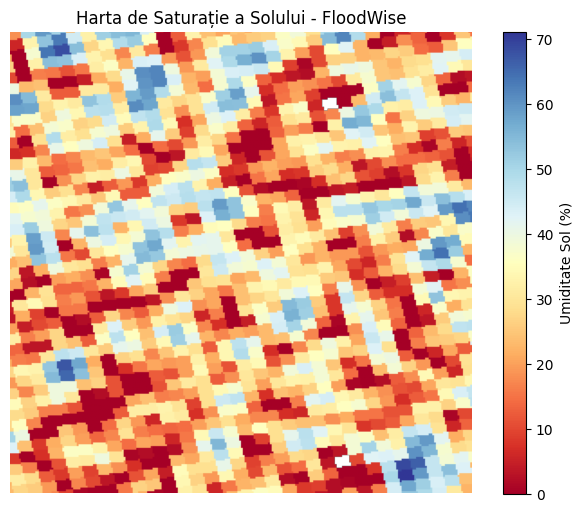

In [29]:
import numpy as np

# 1. Definirea pragurilor (Valorile tipice pentru Sentinel-1 VV în zone agricole)
# NOTĂ: Pentru precizie maximă, aceste valori ar trebui extrase din date istorice.
# În mod normal, valorile Sentinel-1 variază între -20 dB (uscat) și -5 dB (saturat).
DB_DRY = -20.0 
DB_WET = -5.0

# 2. Aplicarea transformării
# Clipim valorile pentru a nu ieși din intervalul definit
arr_clipped = np.clip(arr, DB_DRY, DB_WET)

# Calculăm procentul (Normalizare Min-Max)
soil_moisture_percent = ((arr_clipped - DB_DRY) / (DB_WET - DB_DRY)) * 100

# 3. Afișare
plt.figure(figsize=(8, 6))
plt.imshow(soil_moisture_percent, cmap="RdYlBu") # RdYlBu este intuitiv (Roșu uscat -> Albastru ud)
plt.colorbar(label="Umiditate Sol (%)")
plt.title("Harta de Saturație a Solului - FloodWise")
plt.axis("off")
plt.show()